# A binary's orbit from interferometry at several epochs

This notebook shows virgil's orbit tools end to end. A companion moves on an eccentric Keplerian orbit around its primary, and carries a faint disc that lies in the orbital plane and is brighter on the side facing the primary. We observe the system with the four VLTI Unit Telescopes on six nights spread over most of an orbit, and every sample is simulated at its own time.

We then recover the orbit in the classical way. First we fit a binary to each night separately to get positions. Then a grid search over period, eccentricity and time of periastron gives starting orbits, because at fixed values of those three the positions are linear in the Thiele–Innes constants. Finally we fit the orbit and fluxes jointly to all the visibilities at once. The reader should come away knowing how `KeplerOrbit`, `Attached`, `PositionData`, `starting_orbits` and a time-dependent `fit` fit together.

The first cell sets up the true system. The orbit uses virgil's conventions: `Omega` is the position angle of the node where the secondary recedes, `omega` is the secondary's argument of periastron, and an inclination below 90° means the position angle increases with time. Times are measured from `t_ref`, so they stay precise in float32. The scene is built by a function of the orbital elements and fluxes, which we will reuse for fitting, so that the companion and its disc always share one orbit.

In [1]:
import jax
import numpy as np
import numpyro.distributions as dist
import matplotlib.pyplot as plt
from tqdm.auto import tqdm

from virgil.coverage import vlti_oidata
from virgil.fitting import fit
from virgil.grid_fit import best_grid_point, likelihood_grid
from virgil.inference import laplace_cov
from virgil.models import (
    Attached, BinaryModelCartesian, ModulatedGaussianRim, PointSource, System,
)
from virgil.angles import AngleVector
from virgil.orbits import KeplerOrbit, PositionData, starting_orbits
from virgil.priors import IsotropicInclination

T_REF = 60000.0
ELEMENTS = ("period", "dt_peri", "ecc", "inc", "omega", "Omega", "a_mas")
TRUTH = dict(period=730.0, dt_peri=-100.0, ecc=0.3, inc=50.0, omega=60.0,
             Omega=120.0, a_mas=20.0, flux=0.3, disc_flux=0.02)


def scene(period, dt_peri, ecc, inc, omega, Omega, a_mas, flux, disc_flux):
    orbit = KeplerOrbit(period, dt_peri, ecc, inc, omega, Omega, a_mas, t_ref=T_REF)
    disc = Attached(
        ModulatedGaussianRim(4.0, 1.5, 0.0, 0.0, az_amps=0.5, az_pas=0.0, flux=disc_flux),
        orbit,
        bind={"pa": "node_pa", "inc": "apparent_inc", "az_pas": "towards_primary"},
    )
    return System(primary=PointSource(), comp=Attached(PointSource(flux), orbit), disc=disc)


truth_orbit = KeplerOrbit(*(TRUTH[k] for k in ELEMENTS), t_ref=T_REF)
NIGHTS = T_REF + np.array([0.0, 90.0, 200.0, 330.0, 480.0, 600.0])
sep, pa = truth_orbit.separation_pa(NIGHTS)
for night, s, p in zip(NIGHTS, np.asarray(sep), np.asarray(pa)):
    print(f"MJD {night:.0f}: separation {s:5.1f} mas, position angle {p:5.1f} deg")

MJD 60000: separation  15.4 mas, position angle 273.2 deg
MJD 60090: separation  22.0 mas, position angle 303.5 deg
MJD 60200: separation  21.9 mas, position angle 329.8 deg
MJD 60330: separation  16.8 mas, position angle  12.2 deg
MJD 60480: separation  16.5 mas, position angle  83.9 deg
MJD 60600: separation  13.2 mas, position angle 141.7 deg


Next we simulate the observations. `vlti_oidata` with `nights_mjd` repeats three hour-angle snapshots on each night, in five K-band channels, and gives every snapshot its own time. `with_model` evaluates the moving scene at each sample's time and adds noise with the errors of the coverage (closure phases correlated as for four telescopes). The plot shows the true orbit on the sky, with the companion's position on each night.

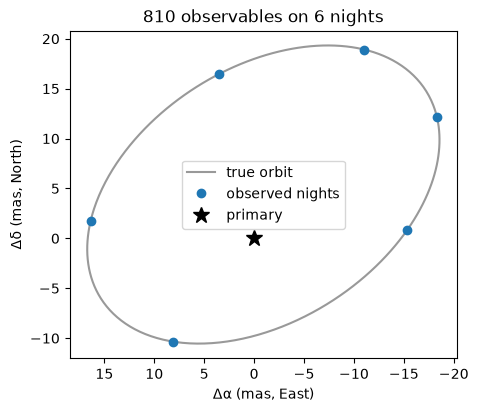

In [2]:
template = vlti_oidata(
    declination_deg=-30.0, hour_angles_h=(-2.0, 0.0, 2.0),
    wavelengths_m=np.linspace(2.0e-6, 2.4e-6, 5),
    sigma_v2=0.02, sigma_cp_deg=1.0, nights_mjd=NIGHTS,
)
data = template.with_model(scene(**TRUTH), key=jax.random.PRNGKey(0))

track = T_REF + np.linspace(0.0, TRUTH["period"], 400)
dra, ddec, _ = truth_orbit.relative(track)
night_dra, night_ddec, _ = truth_orbit.relative(NIGHTS)
fig, ax = plt.subplots(figsize=(5, 5))
ax.plot(dra, ddec, color="0.6", label="true orbit")
ax.plot(night_dra, night_ddec, "o", color="C0", label="observed nights")
ax.plot(0, 0, "*", color="k", ms=12, label="primary")
ax.set(xlabel="Δα (mas, East)", ylabel="Δδ (mas, North)", aspect="equal",
       title=f"{data.n_independent} observables on {len(NIGHTS)} nights")
ax.invert_xaxis()
ax.legend()
plt.show()

For each night separately we fit a plain binary (two point sources), starting from the best point of a coarse grid over the whole field, and take the companion's position and its covariance from the Laplace approximation. `split_by_epoch` gives one dataset per night. The faint disc is ignored here: with extended emission, positions from a two-point fit can be biased, which is why the final fit below uses the visibilities themselves. The result is a `PositionData`, the input to the grid search.

In [3]:
axis = np.linspace(-30.0, 30.0, 61)
grid = {"dra": axis, "ddec": axis, "flux": np.array([0.1, 0.3, 0.6])}
priors = {"dra": dist.Uniform(-40, 40), "ddec": dist.Uniform(-40, 40), "flux": dist.LogUniform(1e-2, 1.0)}
template_binary = BinaryModelCartesian(0.0, 0.0, 0.3)

positions, covariances, times = [], [], []
for night in tqdm(data.split_by_epoch(), desc="nights"):
    start = best_grid_point(likelihood_grid(night, template_binary, grid), grid)
    result = fit(BinaryModelCartesian(**start), priors, night)
    values = [result.values[k] for k in ("dra", "ddec", "flux")]
    cov = laplace_cov(values, ["dra", "ddec", "flux"], night, result.model)
    positions.append(values[:2])
    covariances.append(np.asarray(cov)[:2, :2])
    times.append(float(np.mean(night.mjd)))
positions = np.array(positions)
measured = PositionData(times, positions[:, 0], positions[:, 1], covariances, t_ref=T_REF)

offsets = positions - np.array([night_dra, night_ddec]).T
errors = np.sqrt(np.array([np.diag(c) for c in covariances]))
print("night  Δα error (mas)  Δδ error (mas)   (fitted − true, and 1σ)")
for t, (da, dd), (sa, sd) in zip(times, offsets, errors):
    print(f"{t:7.1f}  {da:+6.3f} ± {sa:.3f}   {dd:+6.3f} ± {sd:.3f}")

nights:   0%|          | 0/6 [00:00<?, ?it/s]

night  Δα error (mas)  Δδ error (mas)   (fitted − true, and 1σ)
60000.0  +0.010 ± 0.009   +0.009 ± 0.010
60090.0  +0.008 ± 0.008   +0.011 ± 0.010
60200.0  -0.004 ± 0.007   +0.008 ± 0.008
60330.0  +0.003 ± 0.010   -0.017 ± 0.011
60480.0  -0.011 ± 0.007   +0.008 ± 0.008
60600.0  -0.013 ± 0.007   +0.011 ± 0.009


Now the grid search for starting orbits. For every trial period, eccentricity and time of periastron, `starting_orbits` solves a weighted linear least-squares problem for the four Thiele–Innes constants, and converts the best solutions back to Keplerian elements. Positions alone fix the node only modulo 180°, so the returned `Omega` lies between 0° and 180°; here the truth (120°) is in that range.

In [4]:
results = starting_orbits(measured, periods=np.geomspace(300.0, 2000.0, 80), n_best=3)
print("        period    ecc    inc  omega  Omega  a_mas     chi2")
print(f"truth  {TRUTH['period']:7.1f}  {TRUTH['ecc']:5.2f}  {TRUTH['inc']:5.1f}"
      f"  {TRUTH['omega']:5.1f}  {TRUTH['Omega']:5.1f}  {TRUTH['a_mas']:5.2f}")
for k, (orbit, chi2) in enumerate(results):
    print(f"start{k} {float(orbit.period):7.1f}  {float(orbit.ecc):5.2f}  {float(orbit.inc):5.1f}"
          f"  {float(orbit.omega):5.1f}  {float(orbit.Omega):5.1f}  {float(orbit.a_mas):5.2f}"
          f"  {chi2:7.2f}")

        period    ecc    inc  omega  Omega  a_mas     chi2
truth    730.0   0.30   50.0   60.0  120.0  20.00
start0   729.5   0.30   49.9   59.4  119.9  19.97  1877.69
start1   747.2   0.30   47.6   55.9  117.9  19.50  41763.21
start2   765.4   0.25   46.3   53.6  122.6  19.40  45424.56


Finally we fit the orbit and both fluxes to all the visibilities and closure phases at once, starting from the best grid orbit. The model is the `scene` function, so `fit` passes the parameters by name and each sample is evaluated at its own time; the disc's orientation follows the orbit throughout. The priors follow the invariant measure of each parameter: log-uniform for the period, semi-major axis and fluxes (scales), uniform for the time of periastron and the eccentricity, `IsotropicInclination` for the inclination (uniform in cos i) and an `AngleVector` for each of ω and Ω, which is uniform on the circle with no edge at 0°/360°. The printout compares the fitted parameters with the truth.

In [5]:
best, _ = results[0]
init = {k: float(getattr(best, k)) for k in ELEMENTS} | {"flux": 0.3, "disc_flux": 0.01}
joint_priors = {
    "period": dist.LogUniform(300.0, 2000.0), "dt_peri": dist.Uniform(-1000.0, 1000.0),
    "ecc": dist.Uniform(0.0, 0.9), "inc": IsotropicInclination(),
    "omega": AngleVector(), "Omega": AngleVector(),
    "a_mas": dist.LogUniform(1.0, 60.0), "flux": dist.LogUniform(1e-2, 1.0),
    "disc_flux": dist.LogUniform(1e-3, 0.2),
}
joint = fit(scene, joint_priors, data, init=init)
print(f"reduced chi2 = {float(joint.info['chi2_red']):.3f}, converged = {joint.info['converged']}")
# AngleVector priors also leave their 2-vectors ("omega_vec", ...) in values.
fitted = {k: float(v) for k, v in joint.values.items() if not k.endswith("_vec")}
# The time of periastron is only defined modulo the period: compare the one
# nearest the truth.
fitted["dt_peri"] -= fitted["period"] * round((fitted["dt_peri"] - TRUTH["dt_peri"]) / fitted["period"])
for name in (*ELEMENTS, "flux", "disc_flux"):
    print(f"{name:10s} truth {TRUTH[name]:8.3f}   fitted {fitted[name]:8.3f}")

reduced chi2 = 1.020, converged = True
period     truth  730.000   fitted  730.035
dt_peri    truth -100.000   fitted -100.070
ecc        truth    0.300   fitted    0.300
inc        truth   50.000   fitted   50.008
omega      truth   60.000   fitted   59.939
Omega      truth  120.000   fitted  120.037
a_mas      truth   20.000   fitted   20.010
flux       truth    0.300   fitted    0.300
disc_flux  truth    0.020   fitted    0.021


We recovered a binary's orbit from interferometric visibilities taken on six nights. Per-night binary fits gave positions, the Thiele–Innes grid search turned them into starting orbits with no random restarts, and a joint fit to all the data refined the orbit and both fluxes, with a disc whose orientation is tied to the orbit. Its fitted ω and Ω may differ from the truth by 180° together: that is the same sky orbit, and only radial velocities, or a component that is not front–back symmetric, can tell the two apart.